In [1]:
### Уровень 1 
import pandas as pd
df = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\train.csv') 
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [2]:
df["age_category"] = df["Age"].apply(lambda x: "взрослый" if x > 17 else "ребенок")
df["счетчик"] = df["Age"].apply(lambda x: 1 )
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,age_category,счетчик
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,взрослый,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,взрослый,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,взрослый,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,взрослый,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,взрослый,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,взрослый,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,взрослый,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,ребенок,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,взрослый,1


In [3]:
res =(df['Age'] < 18).mean()*100 ##
res

np.float64(12.682379349046016)

In [4]:
## Альтернативный вариант
dropped_a = df.dropna(subset=['Age'])## Исключаем пропущенные значение в колонке Age
a=dropped_a['age_category'].value_counts()/len(df)*100
a.loc['ребенок'] ## % детей

np.float64(12.682379349046016)

In [5]:
df['Sex'].value_counts(normalize=True)*100 ##% мужчин и женщин

Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64

In [6]:
## Уровень2
df.isna().sum()##  Посчитать, по скольким людям нет информации (пола или возраста

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             177
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin           687
Embarked          2
age_category      0
счетчик           0
dtype: int64

In [7]:
## Уровень2
dropped_a = df.dropna(subset=['Age'])##  Альтернативный вариант
dropped_b = df.dropna(subset=['Sex'])
print((len(df))-(len(dropped_a)))
print((len(df))-(len(dropped_b)))

177
0


In [8]:
c=df.groupby('Age')[['счетчик']].sum()
c

,счетчик
Age,
0.42,1
0.67,1
0.75,2
0.83,2
0.92,1
...,...
70.00,2
70.50,1
71.00,2


Text(0.5, 0, 'возраст')

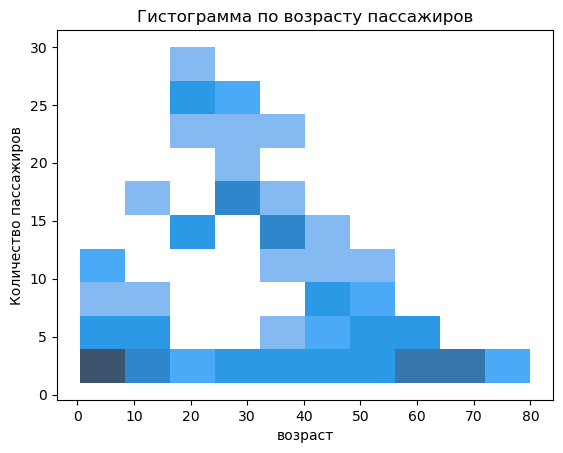

In [9]:
import seaborn as sns
gr=sns.histplot(data=c, x="Age", y="счетчик",bins=10)
gr.set_title("Гистограмма по возрасту пассажиров")
gr.set_ylabel('Количество пассажиров')
gr.set_xlabel("возраст")##Вывести гистограмму по возрасту пассажиров

In [10]:
d= df.groupby('Survived')[['Sex']].sum() ##Посчитать, какой процент мужчин и женщин выжили, какой процент детей выжили.
df["Мужчины"] = df["Sex"].apply(lambda x: 1 if x =='male' else 0)
df["Женщины"] = df["Sex"].apply(lambda x: 0 if x =='male' else 1)
df["Дети"] = df['age_category'].apply(lambda x: 1 if x =='ребенок' else 0)
df.dropna(subset=['Age'])
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,age_category,счетчик,Мужчины,Женщины,Дети
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,взрослый,1,1,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,взрослый,1,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,взрослый,1,0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,взрослый,1,0,1,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,взрослый,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,взрослый,1,1,0,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,взрослый,1,0,1,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,ребенок,1,0,1,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,взрослый,1,1,0,0


In [11]:
df[df['Sex'] == 'female']['Survived'].mean()*100 ## процент выживших женщин

np.float64(74.20382165605095)

In [12]:
df[df['Sex'] == 'male']['Survived'].mean()*100## процент выживших мужчин.

np.float64(18.890814558058924)

In [13]:
adlt=df[df['Age'] >=18]['Survived'].mean()*100## процент выживших взрослых.
adlt

np.float64(38.10316139767055)

In [14]:
chld=df[df['Age'] <=18]['Survived'].mean()*100 ## процент выживших детей.
chld

np.float64(50.35971223021583)

In [15]:
d= df.groupby('Survived')[['Мужчины','Женщины','Дети']].sum()## Альтернативный вариант
d

,Мужчины,Женщины,Дети
Survived,,,
0,468,81,177
1,109,233,113


In [16]:
man=d.loc[1,'Мужчины']/df['Мужчины'].sum()*100 ## процент выживших мужчин.
man

np.float64(18.890814558058924)

In [17]:
fem=d.loc[1,'Женщины']/df['Женщины'].sum()*100 ## процент выживших женщин
fem

np.float64(74.20382165605095)

In [18]:
sur1=df[df['Pclass'] == 1]['Survived'].mean()*100 ## процент выживших 1-ого класса
sur1

np.float64(62.96296296296296)

In [19]:
sur2=df[df['Pclass'] == 2]['Survived'].mean()*100 ## процент выживших 2-ого класса

In [20]:
sur3=df[df['Pclass'] == 3]['Survived'].mean()*100 ## процент выживших 3-ого класса
sur3

np.float64(24.236252545824847)

Text(0.5, 0, 'возраст')

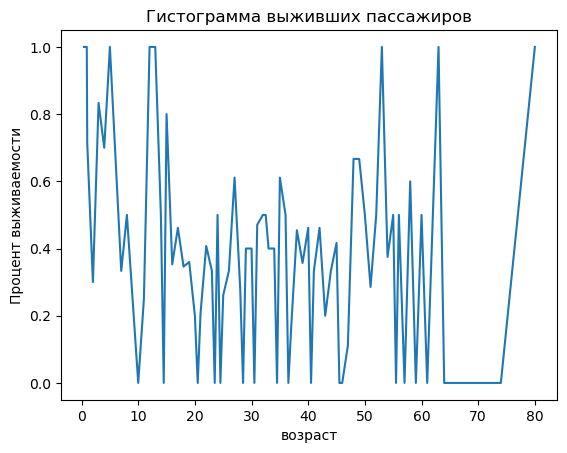

In [21]:
k=df.groupby('Age')[['Survived']].mean()
k
gr2=sns.lineplot(data=k, x="Age", y="Survived")
gr2.set_title("Гистограмма выживших пассажиров")
gr2.set_ylabel('Процент выживаемости')
gr2.set_xlabel("возраст")##Вывести гистограмму по возрасту пассажиров

In [33]:
##Взаимосвязи возраста от выживаемости не обнаружил
worst=(man+adlt+sur3)
worst

np.float64(81.23022850155431)

In [23]:
best= fem+chld+sur1
best

np.float64(187.52649684922974)

In [24]:
cred=(worst+best)/2
cred

np.float64(134.37836267539203)

In [25]:
##df.drop('Ticket',axis=1,inplace=True) -Удаляем ненужные столбцы
##df.drop('Cabin',axis=1,inplace=True)
df['выживание по возрасту']=df["age_category"].apply(lambda x: adlt if x =='взрослый' else chld)
df['выживание по полу']=df["Sex"].apply(lambda x: fem if x =='female' else man)
df['выживание по классу']=df["Pclass"].apply(lambda x: sur1 if x ==1 else( sur2 if x ==2 else sur3))
df['сумма очков']=df['выживание по классу']+df['выживание по полу']+df['выживание по возрасту']
df['Predict']=df["сумма очков"].apply(lambda x: 0 if x <cred else 1)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,age_category,счетчик,Мужчины,Женщины,Дети,выживание по возрасту,выживание по полу,выживание по классу,сумма очков,Predict
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,взрослый,1,1,0,0,38.103161,18.890815,24.236253,81.230229,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,взрослый,1,0,1,0,38.103161,74.203822,62.962963,175.269946,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,взрослый,1,0,1,0,38.103161,74.203822,24.236253,136.543236,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,взрослый,1,0,1,0,38.103161,74.203822,62.962963,175.269946,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,взрослый,1,1,0,0,38.103161,18.890815,24.236253,81.230229,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,...,взрослый,1,1,0,0,38.103161,18.890815,47.282609,104.276585,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,...,взрослый,1,0,1,0,38.103161,74.203822,62.962963,175.269946,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,...,ребенок,1,0,1,1,50.359712,74.203822,24.236253,148.799786,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,...,взрослый,1,1,0,0,38.103161,18.890815,62.962963,119.956939,0


In [26]:
df['errors'] = (df['Survived'] - df['Predict'])
df
df.errors.sum() / df.shape[0]

np.float64(0.031425364758698095)

In [27]:
(1-(df.errors.sum()/df.shape[0]))*100 ## Оцениваем точность прогноза

np.float64(96.8574635241302)

In [28]:
df2 = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\test.csv') 
df2

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [29]:
df2['выживание по возрасту']=df["age_category"].apply(lambda x: adlt if x =='взрослый' else chld)
df2['выживание по полу']=df["Sex"].apply(lambda x: fem if x =='female' else man)
df2['выживание по классу']=df["Pclass"].apply(lambda x: sur1 if x ==1 else( sur2 if x ==2 else sur3))
df2['сумма очков']=df['выживание по классу']+df['выживание по полу']+df['выживание по возрасту']
df2['Survived']=df["сумма очков"].apply(lambda x: 0 if x <cred else 1)
df2

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,выживание по возрасту,выживание по полу,выживание по классу,сумма очков,Survived
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,38.103161,18.890815,24.236253,81.230229,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,38.103161,74.203822,62.962963,175.269946,1
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,38.103161,74.203822,24.236253,136.543236,1
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,38.103161,74.203822,62.962963,175.269946,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,38.103161,18.890815,24.236253,81.230229,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,50.359712,18.890815,47.282609,116.533135,0
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,38.103161,18.890815,24.236253,81.230229,0
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,50.359712,74.203822,24.236253,148.799786,1
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,38.103161,74.203822,47.282609,159.589592,1


In [30]:
prognoz=df2[['PassengerId','Survived']]
prognoz

,PassengerId,Survived
0,892,0
1,893,1
2,894,1
3,895,1
4,896,0
...,...,...
413,1305,0
414,1306,0
415,1307,1
416,1308,1


In [32]:
prognoz.to_csv('prognoz.csv',index=False)